# validation of Neural Population Likelihood

In [1]:
import numpy as np
from tqdm import tqdm

In [2]:
import torch
import tarp
from mira_score import mira
from sbi.inference import NPE

In [3]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [4]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# construct test data

In [5]:
bounds = np.array(UT._prior_range_default())[:-1]

In [6]:
# construct test data
Nmocks = 1000

_test_omegas = np.array([
    np.random.uniform(bounds[0][0], bounds[0][1], size=Nmocks),
    np.random.uniform(bounds[1][0], bounds[1][1], size=Nmocks),
    np.random.uniform(bounds[2][0], bounds[2][1], size=Nmocks),
    np.random.uniform(bounds[3][0], bounds[3][1], size=Nmocks)
]).T

i_comp = [] 
test_Xsig_z14, test_Xsig_z11, test_Xsig_z9 = [], [], []
for ii in tqdm(range(Nmocks)): 
    # forward model 
    mock = FM.sampleLF(_test_omegas[ii], phi_amp=6e-3)

    results = [] 
    for name in ('z14', 'z11', 'z9'):
        obs = FM.apply_selection_noise(mock, name) 
        if obs.shape[0] == 0: continue
        i = np.random.randint(obs.shape[0])
        results.append(obs[i])
    if len(results) < 3: continue
    i_comp.append(ii)
    test_Xsig_z14.append(results[0])
    test_Xsig_z11.append(results[1])
    test_Xsig_z9.append(results[2])

test_omegas = _test_omegas[np.array(i_comp)]
test_Xsig_z14 = np.array(test_Xsig_z14)
test_Xsig_z11 = np.array(test_Xsig_z11)
test_Xsig_z9 = np.array(test_Xsig_z9)

np.save('/Users/ch54662/data/px2cosmo/mock/test_population_omega.npy', test_omegas)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z14_Xsig.npy', test_Xsig_z14)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z11_Xsig.npy', test_Xsig_z11)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z9_Xsig.npy', test_Xsig_z9)    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:06<00:00,  7.91it/s]


In [6]:
test_omegas = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_omega.npy')
test_Xsig_z14 = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z14_Xsig.npy')
test_Xsig_z11 = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z11_Xsig.npy')
test_Xsig_z9 = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z9_Xsig.npy')

In [7]:
def validate_NLE(model_name, test_Xsig): 
    p_X_omegasig_S = torch.load(model_name, weights_only=False)
    
    test_omegasig = torch.tensor(np.hstack([test_omegas, test_Xsig[:,-2:]]).astype(np.float32))
    test_X = torch.tensor(test_Xsig[:,:2].astype(np.float32))

    test_samples = p_X_omegasig_S.sample_batched((1000,), x=test_omegasig, show_progress_bars=False)

    ecp, alpha = tarp.get_tarp_coverage(test_samples.numpy(), test_X.numpy())
    mean_score, std_score = mira(test_X, test_samples[None,:].permute(0, 2, 1, 3), num_runs=100)
    return ecp, alpha, mean_score, std_score

# validate $z=14$ NLE

In [15]:
ecp_z14, alpha_z14, mean_score_z14, std_score_z14 = validate_NLE(
    '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_v1_pop_k10/q_X_omegasig_z14_v1_pop_k10.21.pt', 
    test_Xsig_z14)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 446.67it/s]


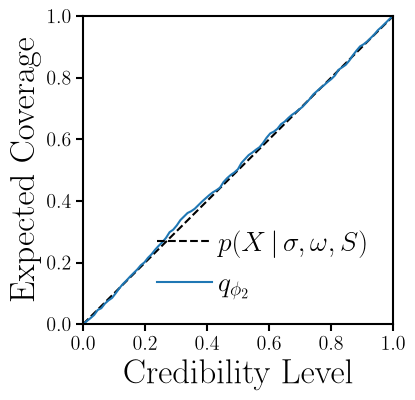

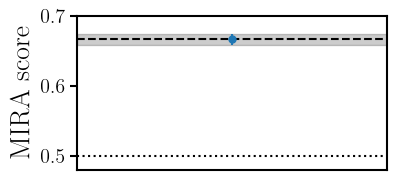

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z14, ecp_z14, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
plt.show()

L = test_omegas.shape[0]
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z14.item()], yerr=[std_score_z14.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
plt.show()

# validate $z=11$ NLE

In [19]:
ecp_z11, alpha_z11, mean_score_z11, std_score_z11 = validate_NLE(
    '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z11_v1_pop_k10/q_X_omegasig_z11_v1_pop_k10.42.pt', 
    test_Xsig_z11)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 448.56it/s]


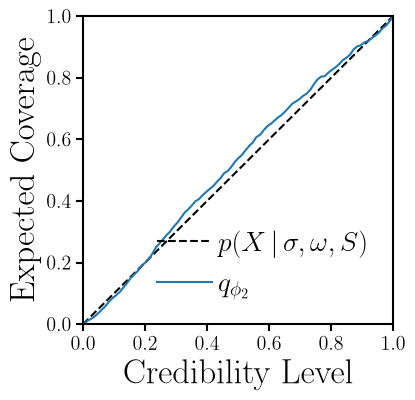

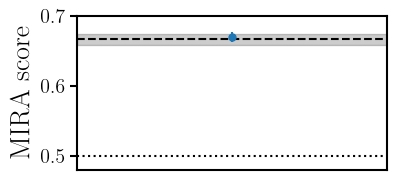

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z11, ecp_z11, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
plt.show()

fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z11.item()], yerr=[std_score_z11.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
plt.show()

# validate $z=9$ NLE

In [8]:
ecp_z9, alpha_z9, mean_score_z9, std_score_z9 = validate_NLE(
    '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.9.pt', 
    test_Xsig_z9)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 256.11it/s]


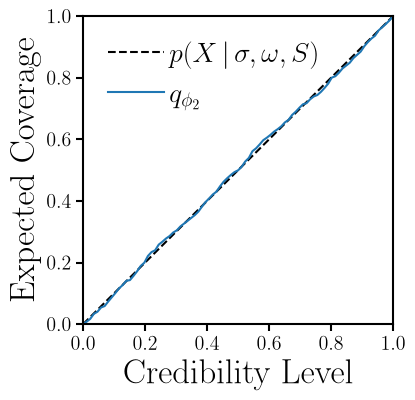

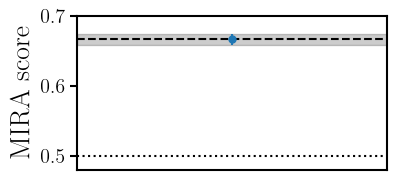

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z9, ecp_z9, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
plt.show()

L = test_omegas.shape[0]
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z9.item()], yerr=[std_score_z9.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
plt.show()

# validation plots

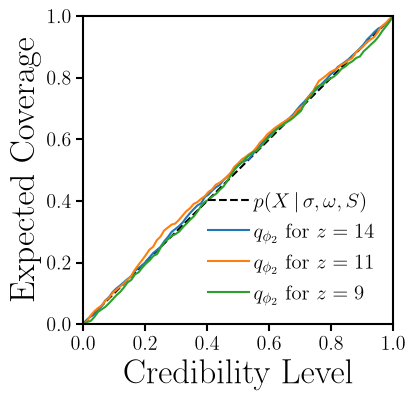

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z14, ecp_z14, label=r'$q_{\phi_2}$ for $z=14$')
ax.plot(alpha_z11, ecp_z11, label=r'$q_{\phi_2}$ for $z=11$')
ax.plot(alpha_z9, ecp_z9, label=r'$q_{\phi_2}$ for $z=9$')
ax.legend(fontsize=15, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
fig.savefig('likelihood_tarp.pdf', bbox_inches='tight') 

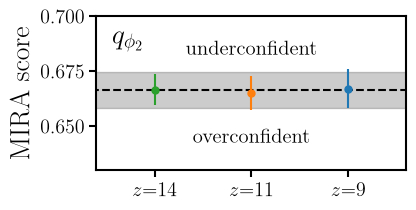

In [27]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')

sub.errorbar([0.25], [mean_score_z14.item()], yerr=[std_score_z14.item()], c='C2', fmt='o', markersize=5)
sub.errorbar([0.50], [mean_score_z11.item()], yerr=[std_score_z11.item()], c='C1', fmt='o', markersize=5)
sub.errorbar([0.75], [mean_score_z9.item()], yerr=[std_score_z9.item()], c='C0', fmt='o', markersize=5)

sub.text(0.5, 0.685, 'underconfident', ha='center', va='center', fontsize=15)
sub.text(0.5, 0.645, 'overconfident', ha='center', va='center', fontsize=15)

sub.text(0.05, 0.95, r'$q_{\phi_2}$', fontsize=20, transform=sub.transAxes, ha='left', va='top')
sub.set_xlim(0.1, 0.9)
sub.set_xticks([0.25, 0.5, 0.75])
sub.set_xticklabels(['$z{=}14$', '$z{=}11$', '$z{=}9$'])
sub.set_ylim(0.63, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
fig.savefig('likelihood_mira.pdf', bbox_inches='tight') 

# test variation among different NDEs

In [11]:
import emcee

In [12]:
omega_true = np.load("/Users/ch54662/data/px2cosmo/mock/omega_true.npy")
X_obs_z14 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy")
X_obs_z11 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy")
X_obs_z9 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy")

_X_obs_z14 = torch.tensor(X_obs_z14[:,:2].astype(np.float32))
_X_obs_z11 = torch.tensor(X_obs_z11[:,:2].astype(np.float32))
_X_obs_z9 = torch.tensor(X_obs_z9[:,:2].astype(np.float32))

_sig_obs_z14 = torch.tensor(X_obs_z14[:,2:].astype(np.float32))
_sig_obs_z11 = torch.tensor(X_obs_z11[:,2:].astype(np.float32))
_sig_obs_z9 = torch.tensor(X_obs_z9[:,2:].astype(np.float32))

In [25]:
def log_prior(omega): 
    alpha, beta, gamma, Muv_s = omega
    if (bounds[0][0] < alpha < bounds[0][1] and 
        bounds[1][0] < beta < bounds[1][1] and 
        bounds[2][0] < gamma < bounds[2][1] and 
        bounds[3][0] < Muv_s < bounds[3][1]):
        return 0.
    return -np.inf

def test_likelihood(zbin, fmodels, _X_obs, _sig_obs): 
    #_X_obs = {'z14': _X_obs_z14, 'z11': _X_obs_z11[:1], 'z9': _X_obs_z9[:1]}[zbin]
    #_sig_obs = {'z14': _sig_obs_z14, 'z11': _sig_obs_z11[:1], 'z9': _sig_obs_z9[:1]}[zbin]
    
    ndim, nwalkers = 4, 10
    mcmc_samplers = [] 
    for fmodel in fmodels: 
        p_X_omegasig_S = torch.load(fmodel, weights_only=False, map_location='cpu')
        
        def _log_p(omega, silent=True): 
            lp = log_prior(omega) # prior 
            if not np.isfinite(lp): return -np.inf
            
            # log likelihood
            _omega = torch.tensor(omega.astype(np.float32))
            _omegasig = torch.cat([_omega.expand(_X_obs.shape[0], -1), _sig_obs], dim=1)
            with torch.no_grad(): 
                return p_X_omegasig_S.log_prob_batched(_X_obs, _omegasig, norm_posterior=False).sum().item()

        
        p0 = np.array([
            np.random.uniform(bounds[0][0], bounds[0][1], nwalkers),
            np.random.uniform(bounds[1][0], bounds[1][1], nwalkers),
            np.random.uniform(bounds[2][0], bounds[2][1], nwalkers),
            np.random.uniform(bounds[3][0], bounds[3][1], nwalkers)
        ]).T
        
        sampler = emcee.EnsembleSampler(nwalkers, ndim, _log_p)
        _ = sampler.run_mcmc(p0, 10000, progress=True)
        mcmc_samplers.append(sampler)
    
    return mcmc_samplers

In [17]:
mcmc_z14 = test_likelihood('z14',
                        ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_v1_pop_k10/q_X_omegasig_z14_v1_pop_k10.21.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_v1_pop_k10/q_X_omegasig_z14_v1_pop_k10.29.pt', 
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_v1_pop_k10/q_X_omegasig_z14_v1_pop_k10.66.pt'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:17<00:00, 128.67it/s]


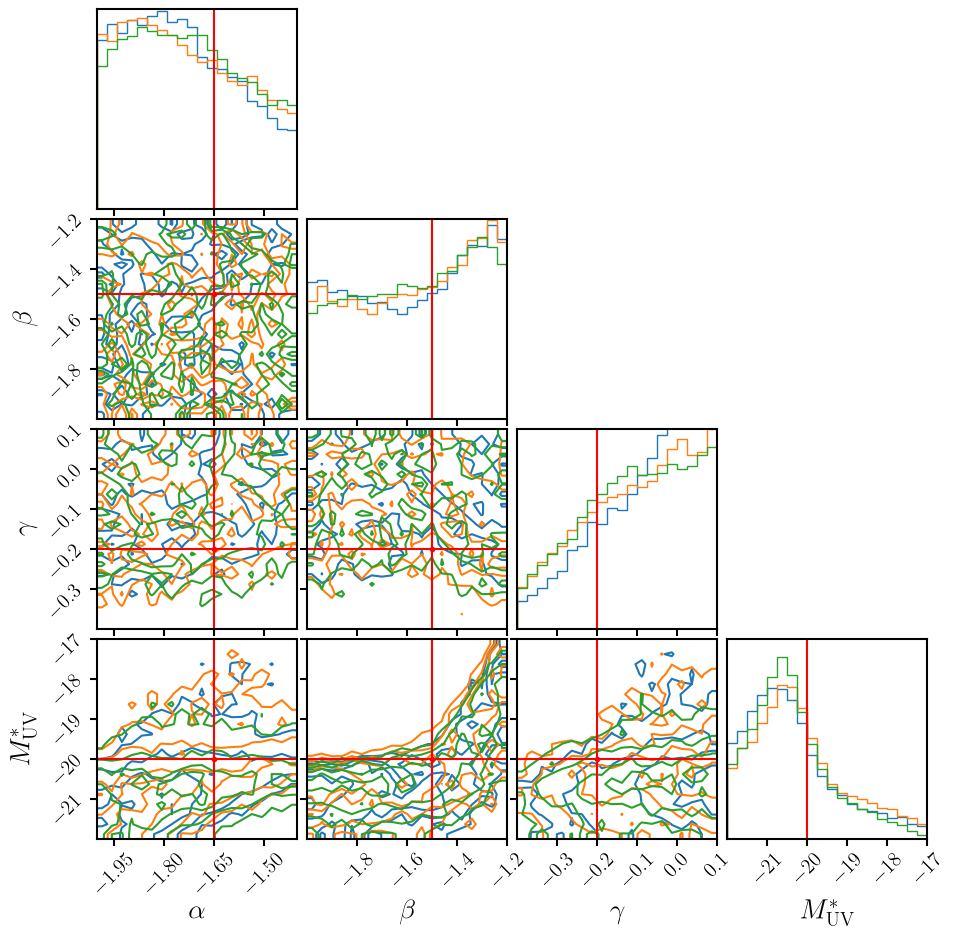

In [18]:
fig = None
for i, _mcmc in enumerate(mcmc_z14): 
    fig = DFM.corner(_mcmc.flatchain[5000:,:], color='C%i' % i, plot_density=False, plot_datapoints=False, 
                     range=bounds, hist_kwargs={'density': True}, 
                     labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'], label_kwargs={'fontsize': 20}, 
                     fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig, omega_true[:-1], color='red')

In [27]:
mcmc_z11 = test_likelihood('z11',
                        ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z11_v1_pop_k10/q_X_omegasig_z11_v1_pop_k10.42.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z11_v1_pop_k10/q_X_omegasig_z11_v1_pop_k10.26.pt', 
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z11_v1_pop_k10/q_X_omegasig_z11_v1_pop_k10.43.pt']
                         )

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:51<00:00, 195.68it/s]


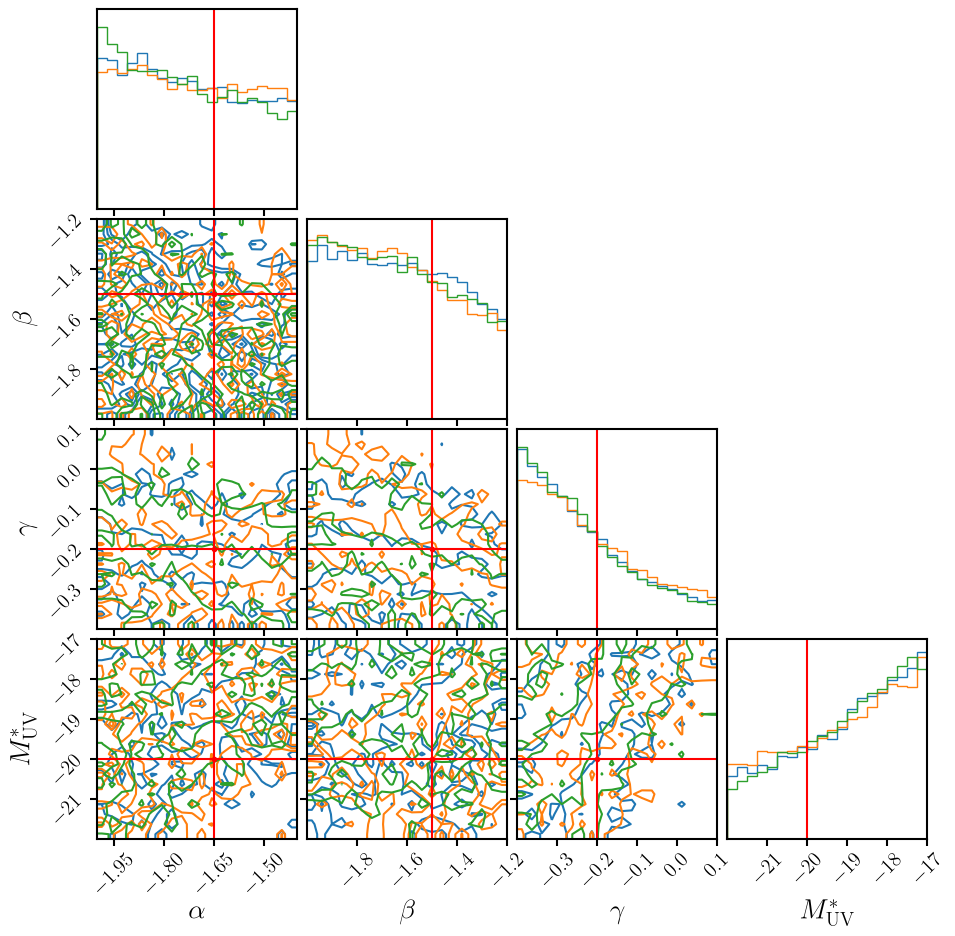

In [28]:
fig = None
for i, _mcmc in enumerate(mcmc_z11): 
    fig = DFM.corner(_mcmc.flatchain[5000:,:], color='C%i' % i, plot_density=False, plot_datapoints=False, 
                     range=bounds, hist_kwargs={'density': True}, 
                     labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'], label_kwargs={'fontsize': 20}, 
                     fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig, omega_true[:-1], color='red')

In [23]:
mcmc_z9 = test_likelihood('z9',
                        ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.9.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.24.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.34.pt'], 
                          _X_obs_z9[:1], _sig_obs_z9[:1])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:28<00:00, 351.67it/s]


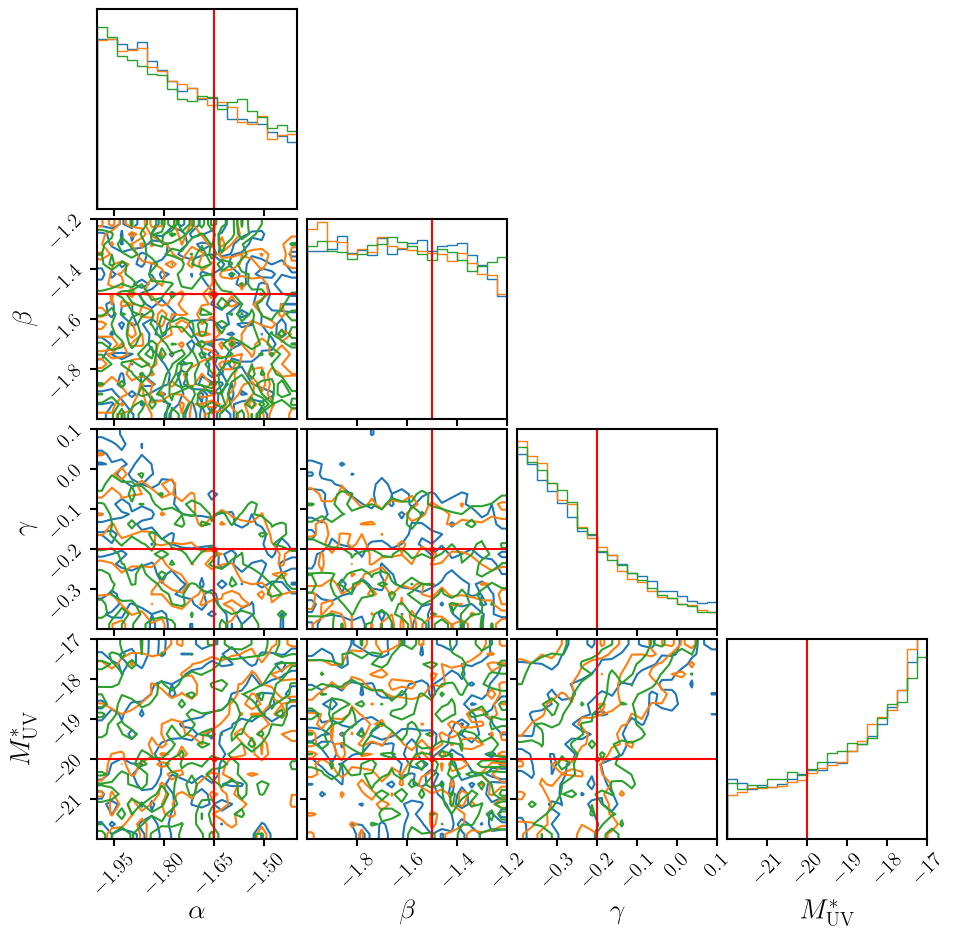

In [24]:
fig = None
for i, _mcmc in enumerate(mcmc_z9): 
    fig = DFM.corner(_mcmc.flatchain[5000:,:], color='C%i' % i, plot_density=False, plot_datapoints=False, 
                     range=bounds, hist_kwargs={'density': True}, 
                     labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'], label_kwargs={'fontsize': 20}, 
                     fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig, omega_true[:-1], color='red')

In [26]:
mcmc_z9 = test_likelihood('z9',
                        ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.9.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.24.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.34.pt'], 
                          _X_obs_z9[1:2], _sig_obs_z9[1:2])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:28<00:00, 355.62it/s]


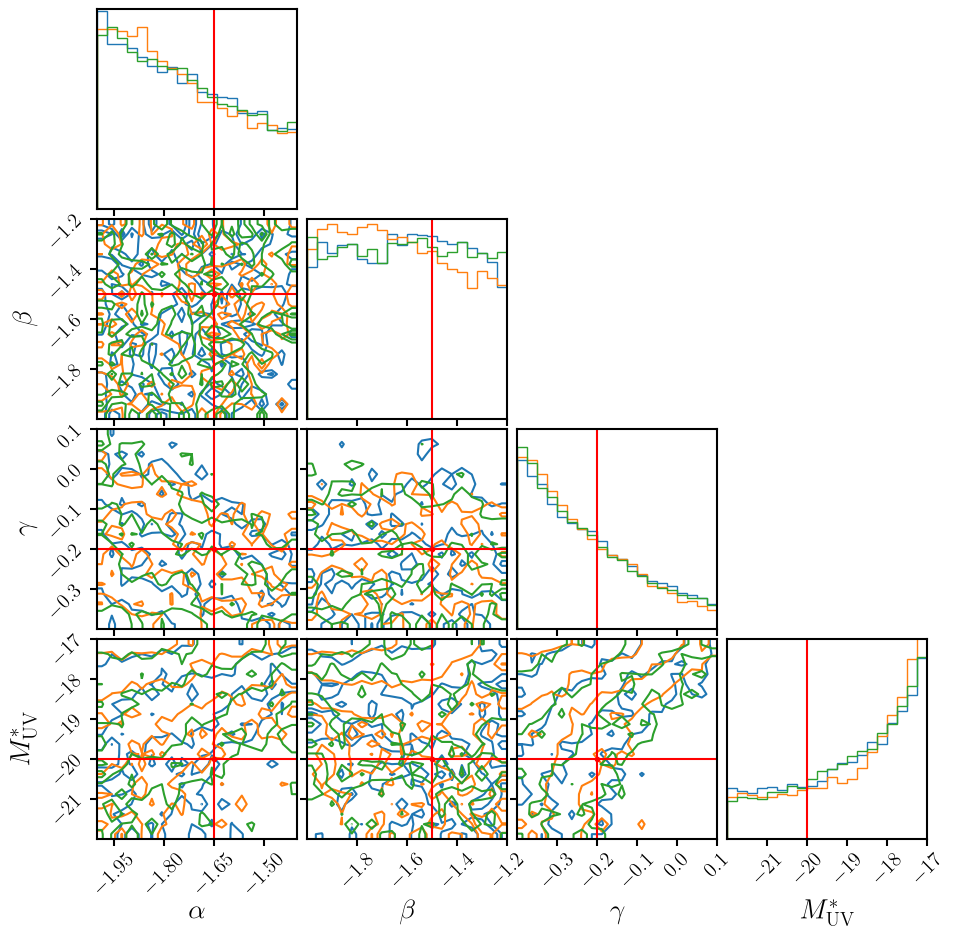

In [27]:
fig = None
for i, _mcmc in enumerate(mcmc_z9): 
    fig = DFM.corner(_mcmc.flatchain[5000:,:], color='C%i' % i, plot_density=False, plot_datapoints=False, 
                     range=bounds, hist_kwargs={'density': True}, 
                     labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'], label_kwargs={'fontsize': 20}, 
                     fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig, omega_true[:-1], color='red')

In [43]:
mcmc_z9 = test_likelihood('z9',
                        ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.9.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.24.pt',
                         '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_v1_pop_k100/q_X_omegasig_z9_v1_pop_k100.34.pt'], 
                          _X_obs_z9[::2], _sig_obs_z9[::2])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:34<00:00, 46.61it/s]


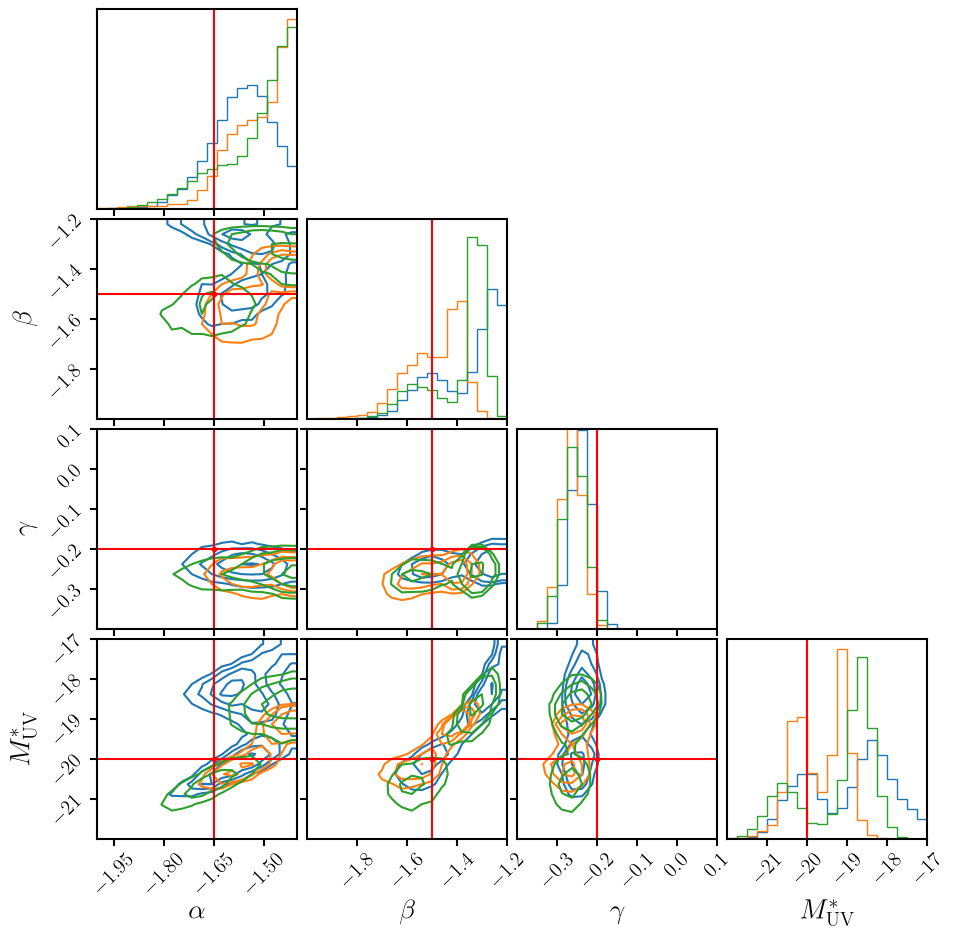

In [44]:
fig = None
for i, _mcmc in enumerate(mcmc_z9): 
    fig = DFM.corner(_mcmc.flatchain[5000:,:], color='C%i' % i, plot_density=False, plot_datapoints=False, 
                     range=bounds, hist_kwargs={'density': True}, 
                     labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'], label_kwargs={'fontsize': 20}, 
                     fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig, omega_true[:-1], color='red')